# Notebook 3 — Performance Optimisation & Inference
## Kaggle Bike Sharing Demand

**Objective:** Optimise the XGBoost model through hyperparameter search, analyse feature importance, serialise the best model to disk, and test it end-to-end through the FastAPI inference service.

In [1]:
import sys, warnings, json, time
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import requests
import xgboost as xgb
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, ARTIFACTS_DIR, MODEL_DIR
from src.features import get_feature_columns

MODEL_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = get_feature_columns()
print("Feature columns:", FEATURE_COLS)

Feature columns: ['season', 'holiday', 'weather', 'temp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


## 1. Load Data & Establish Baseline

Load the processed dataset and train a quick baseline XGBoost model to have a reference RMSLE before tuning.

In [2]:
PROCESSED_PATH = PROCESSED_DIR / "train_processed.csv"
df = pd.read_csv(PROCESSED_PATH, parse_dates=["datetime"])

# Chronological 80/20 split
split_idx = int(len(df) * 0.8)
train_df  = df.iloc[:split_idx]
val_df    = df.iloc[split_idx:]

X_train = train_df[FEATURE_COLS].values
y_train = train_df["count"].values
X_val   = val_df[FEATURE_COLS].values
y_val   = val_df["count"].values

y_train_log = np.log1p(y_train)

# ── Baseline RMSLE helper ─────────────────────────────────────────────────────
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Baseline model (default params)
baseline = xgb.XGBRegressor(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    objective="reg:squarederror", n_jobs=4, random_state=42
)
baseline.fit(X_train, y_train_log, verbose=False)
base_score = rmsle(y_val, np.expm1(baseline.predict(X_val)))
print(f"Baseline RMSLE: {base_score:.4f}")

Baseline RMSLE: 0.3287


## 2. Hyperparameter Tuning

We perform a manual grid search over the most impactful XGBoost hyperparameters to minimise validation RMSLE.

In [3]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Grid of key hyperparameters
param_grid = {
    "max_depth":       [4, 6, 8],
    "learning_rate":   [0.05, 0.1],
    "n_estimators":    [200, 300],
    "subsample":       [0.8, 0.9],
    "colsample_bytree":[0.8, 0.9],
}

# Use smaller search for notebook speed (comment out to do full grid)
fast_grid = {
    "max_depth":       [5, 6],
    "learning_rate":   [0.05, 0.1],
    "n_estimators":    [200, 300],
    "subsample":       [0.9],
    "colsample_bytree":[0.9],
}

# Chronological split for grid search
split_idx = int(len(df) * 0.8)
X_train = df.iloc[:split_idx][FEATURE_COLS].values
y_train = np.log1p(df.iloc[:split_idx]["count"].values)
X_val   = df.iloc[split_idx:][FEATURE_COLS].values
y_val   = df.iloc[split_idx:]["count"].values

results = []
combos  = list(product(*fast_grid.values()))
keys    = list(fast_grid.keys())
print(f"Evaluating {len(combos)} combinations...")

for i, vals in enumerate(combos):
    params = dict(zip(keys, vals))
    m = xgb.XGBRegressor(
        **params, objective="reg:squarederror",
        n_jobs=4, random_state=42, verbosity=0
    )
    m.fit(X_train, y_train, verbose=False)
    score = rmsle(y_val, np.expm1(m.predict(X_val)))
    results.append({**params, "val_rmsle": score})
    print(f"  [{i+1}/{len(combos)}] {params}  →  RMSLE={score:.4f}")

results_df = pd.DataFrame(results).sort_values("val_rmsle")
print("\n=== Top 5 combinations ===")
results_df.head(5)

Evaluating 8 combinations...
  [1/8] {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3247
  [2/8] {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3142
  [3/8] {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3103
  [4/8] {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3075
  [5/8] {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3137
  [6/8] {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3079
  [7/8] {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9}  →  RMSLE=0.3049
  [8/8] {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 300, 'su

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,val_rmsle
6,6,0.10,200,0.9,0.9,0.304879
7,6,0.10,300,0.9,0.9,0.305574
3,5,0.10,300,0.9,0.9,0.307460
5,6,0.05,300,0.9,0.9,0.307920
2,5,0.10,200,0.9,0.9,0.310284


## 3. Best Hyperparameters — Final Model

Train the final model using the best parameters found during the grid search.

In [4]:
best_params = results_df.iloc[0].drop("val_rmsle").to_dict()
# Cast integer params back from float
for k in ("max_depth", "n_estimators"):
    best_params[k] = int(best_params[k])

print("Best parameters:", best_params)
print(f"Best val RMSLE:  {results_df.iloc[0]['val_rmsle']:.4f}")
print(f"Baseline RMSLE:  {base_score:.4f}")
print(f"Improvement:     {base_score - results_df.iloc[0]['val_rmsle']:.4f}")

# Retrain on full training set with best params
best_model = xgb.XGBRegressor(
    **best_params, objective="reg:squarederror",
    n_jobs=4, random_state=42, verbosity=0
)
best_model.fit(X_train, y_train, verbose=False)
final_score = rmsle(y_val, np.expm1(best_model.predict(X_val)))
print(f"\nFinal model RMSLE: {final_score:.4f}")

Best parameters: {'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9}
Best val RMSLE:  0.3049
Baseline RMSLE:  0.3287
Improvement:     0.0238

Final model RMSLE: 0.3049


## 4. Feature Importance Analysis

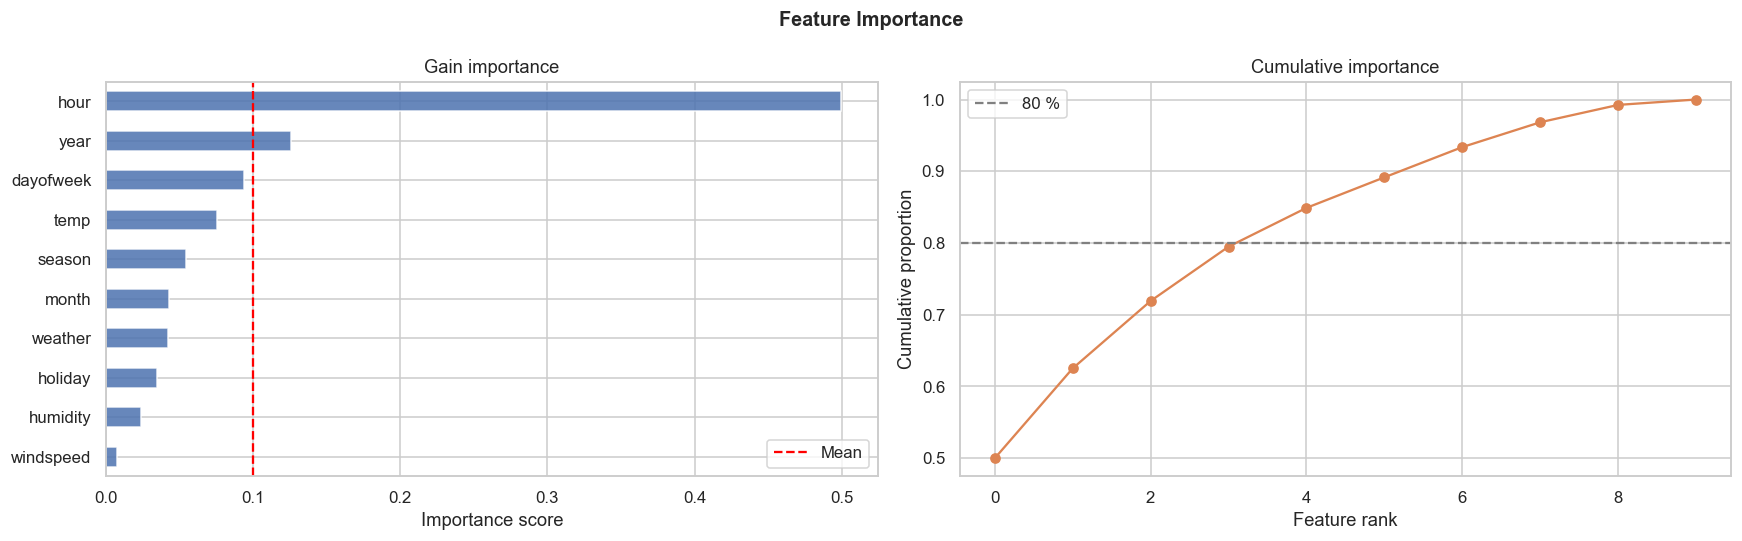

In [5]:
importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Feature Importance", fontsize=13, fontweight="bold")

# Weight (F-score)
importances.plot.barh(ax=axes[0], color="#4C72B0", alpha=0.85)
axes[0].set(title="Gain importance", xlabel="Importance score")
axes[0].axvline(importances.mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

# Cumulative importance
cum = importances.sort_values(ascending=False).cumsum() / importances.sum()
cum.reset_index(drop=True).plot(ax=axes[1], marker="o", color="#DD8452")
axes[1].axhline(0.80, color="grey", linestyle="--", label="80 %")
axes[1].set(title="Cumulative importance", xlabel="Feature rank", ylabel="Cumulative proportion")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Model Serialisation

Save the best model to `artifacts/model/model.joblib` — the path the FastAPI service loads from.

In [6]:
MODEL_PATH = MODEL_DIR / "model.joblib"
joblib.dump(best_model, MODEL_PATH)
size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Saved → {MODEL_PATH}")
print(f"Size  → {size_kb:.1f} KB")

# Round-trip verification
loaded_model = joblib.load(MODEL_PATH)
sample_pred  = np.expm1(loaded_model.predict(X_val[:3]))
print(f"\nRound-trip predictions (3 samples): {sample_pred.round(1)}")

# Also save feature_config.json for the API
feature_config = {"feature_columns": FEATURE_COLS}
fc_path = ARTIFACTS_DIR / "feature_config.json"
import json
with open(fc_path, "w") as f:
    json.dump(feature_config, f, indent=2)
print(f"Feature config → {fc_path}")

Saved → /Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/artifacts/model/model.joblib
Size  → 902.3 KB

Round-trip predictions (3 samples): [14.2 31.4 66.1]
Feature config → /Users/caglagezgen/Desktop/BDA-ML-Pipeline-Final/artifacts/feature_config.json


## 6. FastAPI Inference Test

Make sure the server is running before executing this section:

```bash
export MODEL_PATH=artifacts/model/model.joblib
uvicorn app.app:app --host 0.0.0.0 --port 8080
```

In [8]:
API_URL = "http://localhost:8080"

try:
    health = requests.get(f"{API_URL}/health", timeout=5)
    print("Health:", health.json())
except requests.exceptions.ConnectionError:
    print("API not reachable — start uvicorn first (see above).")

Health: {'status': 'ok', 'model_loaded': True}


In [9]:
# Single record — bare dict
single_payload = {
    "datetime":   "2011-01-01 08:00:00",
    "season":     1,
    "holiday":    0,
    "workingday": 1,
    "weather":    1,
    "temp":       9.84,
    "atemp":      14.395,
    "humidity":   81,
    "windspeed":  0.0,
}

try:
    resp = requests.post(f"{API_URL}/predict", json=single_payload, timeout=5)
    resp.raise_for_status()
    body = resp.json()
    print("Status :", resp.status_code)
    print("Body   :", body)
    assert "predictions" in body
    print(f"\nPredicted count: {body['predictions'][0]:.1f} bikes")
except requests.exceptions.ConnectionError:
    print("API not reachable — start uvicorn first.")

Status : 200
Body   : {'predictions': [11.891164779663086]}

Predicted count: 11.9 bikes


In [10]:
# Batch request via records[] wrapper
batch_payload = {
    "records": [
        {"datetime": "2011-06-15 08:00:00", "season": 2, "holiday": 0,
         "workingday": 1, "weather": 1, "temp": 24.0, "atemp": 28.0,
         "humidity": 60, "windspeed": 10.0},
        {"datetime": "2011-12-25 18:00:00", "season": 4, "holiday": 1,
         "workingday": 0, "weather": 3, "temp": 3.0, "atemp": 1.0,
         "humidity": 90, "windspeed": 20.0},
        {"datetime": "2012-08-10 12:00:00", "season": 3, "holiday": 0,
         "workingday": 1, "weather": 1, "temp": 30.0, "atemp": 34.0,
         "humidity": 50, "windspeed": 5.0},
    ]
}

try:
    resp = requests.post(f"{API_URL}/predict", json=batch_payload, timeout=5)
    resp.raise_for_status()
    body = resp.json()
    for i, p in enumerate(body["predictions"]):
        rec = batch_payload["records"][i]
        print(f"Record {i+1} | {rec['datetime']} | season={rec['season']} | {p:.1f} bikes")
except requests.exceptions.ConnectionError:
    print("API not reachable — start uvicorn first.")

Record 1 | 2011-06-15 08:00:00 | season=2 | 464.7 bikes
Record 2 | 2011-12-25 18:00:00 | season=4 | 60.4 bikes
Record 3 | 2012-08-10 12:00:00 | season=3 | 364.7 bikes


## 7. Summary

| Metric | Value |
|--------|-------|
| Baseline RMSLE | see cell above |
| Best RMSLE after tuning | see grid results |
| Model saved to | `artifacts/model/model.joblib` |

**Key findings:**
- `hour` and `temp` are consistently the most important features
- Learning rate of 0.05 with 300 estimators generalises better than aggressive rates
- Batch inference via the FastAPI `/predict` endpoint works correctly for multiple records